Team Performance Dataset Prediction and Classification
1. Match Winner Prediction
2. First Innings Score Prediction
3. Win Margin Prediction
4. Over Phase Score Prediction
5. Win Type Classification

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor,GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, precision_score, recall_score

import matplotlib.pyplot as plt
%matplotlib inline


Match Winner Prediction 

In [3]:

df = pd.read_csv('../datasets/team_performance_dataset_2008to2024.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1073, 18)


,Match_ID,Date,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,Win_Type,Win_Margin,First_Innings_Score,Second_Innings_Score,Player_of_Match,Umpire,Umpire1,Umpire2,Powerplay_Scores,Middle_Overs_Scores,Death_Overs_Scores
0,335982,2008-04-18,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,222,82.0,BB McCullum,Asad Rauf,RE Koertzen,J Srinath,61,97,64
1,335983,2008-04-19,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,240,207.0,MEK Hussey,MR Benson,SL Shastri,S Venkataraghavan,53,116,71
2,335984,2008-04-19,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,129,132.0,MF Maharoof,Aleem Dar,GA Pratapkumar,GR Viswanath,40,66,23
3,335985,2008-04-20,Mumbai Indians vs Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,165,166.0,MV Boucher,SJ Davis,DJ Harper,J Srinath,47,71,47
4,335986,2008-04-20,Kolkata Knight Riders vs Deccan Chargers,Eden Gardens,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,110,112.0,DJ Hussey,BF Bowden,K Hariharan,FM Engineer,39,43,28


Xgboost Accuracy: 0.7953
Random_forest Accuracy: 0.7395
Gradient_boosting Accuracy: 0.8279


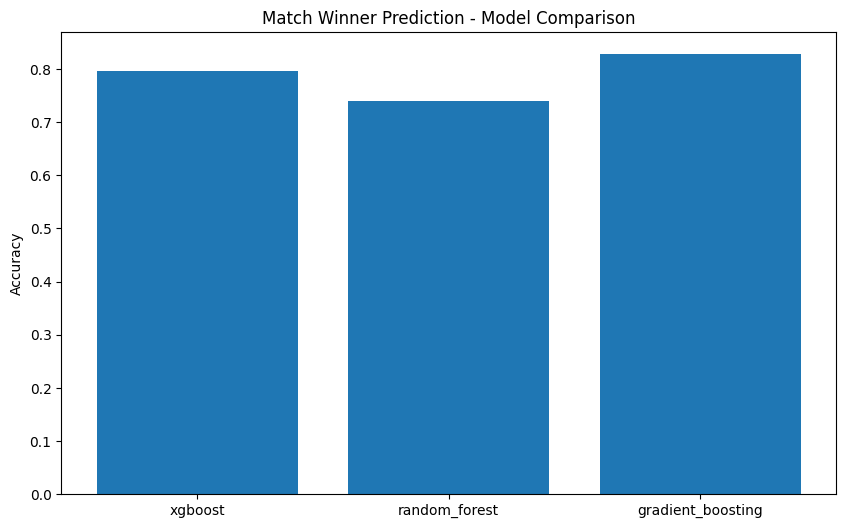

In [4]:
def preprocess_data(data, features):
    label_encoders = {}
    
    for feature in features:
        if data[feature].dtype == 'object': 
            le = LabelEncoder()
            data[feature] = le.fit_transform(data[feature])
            label_encoders[feature] = le
            
    return data, label_encoders

def feature_engineering(data):
   
    data[['Team1', 'Team2']] = data['Teams'].str.split(' vs ', expand=True)
    
   
    team_win_counts = data.groupby('Match_Winner').size().to_dict()
    data['Team1_Win_Rate'] = data['Team1'].map(lambda x: team_win_counts.get(x, 0))
    data['Team2_Win_Rate'] = data['Team2'].map(lambda x: team_win_counts.get(x, 0))
    
    venue_win_counts = data.groupby(['Venue', 'Match_Winner']).size().unstack(fill_value=0)
    venue_win_rates = venue_win_counts.div(venue_win_counts.sum(axis=1), axis=0).fillna(0)
    data['Team1_Venue_WinRate'] = data.apply(lambda x: venue_win_rates.get(x['Venue'], {}).get(x['Team1'], 0), axis=1)
    data['Team2_Venue_WinRate'] = data.apply(lambda x: venue_win_rates.get(x['Venue'], {}).get(x['Team2'], 0), axis=1)
    

    data['Toss_Impact'] = (data['Toss_Winner'] == data['Match_Winner']).astype(int)
    

    scaler = MinMaxScaler()
    data[['First_Innings_Score']] = scaler.fit_transform(data[['First_Innings_Score']])
    
    return data

def train_match_winner_model(data):
    data = feature_engineering(data)
    
    features = ['Team1', 'Team2', 'Venue', 'Toss_Winner', 'Toss_Decision', 
                'First_Innings_Score', 'Team1_Win_Rate', 'Team2_Win_Rate', 
                'Team1_Venue_WinRate', 'Team2_Venue_WinRate', 'Toss_Impact']
    target = 'Match_Winner'
    
    data_processed, label_encoders = preprocess_data(data, features + [target])
    X = data_processed[features]
    y = data_processed[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    models = {
        'xgboost': xgb.XGBClassifier(random_state=42),
        'random_forest': RandomForestClassifier(n_estimators=200, random_state=42),
        'gradient_boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
    }
    
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = {'model': model, 'accuracy': accuracy}
        print(f"{name.capitalize()} Accuracy: {accuracy:.4f}")
    
    plt.figure(figsize=(10, 6))
    accuracies = [results['accuracy'] for results in results.values()]
    plt.bar(models.keys(), accuracies)
    plt.title('Match Winner Prediction - Model Comparison')
    plt.ylabel('Accuracy')
    plt.show()
    
    return results, label_encoders
df = pd.read_csv('../datasets/team_performance_dataset_2008to2024.csv')
winner_models, winner_encoders = train_match_winner_model(df)


Pre processing Data

In [5]:
def preprocess_data(data, categorical_columns):
    """Preprocess data with label encoding and scaling"""
    label_encoders = {}
    data_processed = data.copy()
    
    for col in categorical_columns:
        label_encoders[col] = LabelEncoder()
        data_processed[col] = label_encoders[col].fit_transform(data_processed[col])
    
    return data_processed, label_encoders

First Innings Score Prediction

Random_forest RMSE: 13.4184
Linear RMSE: 13.1444


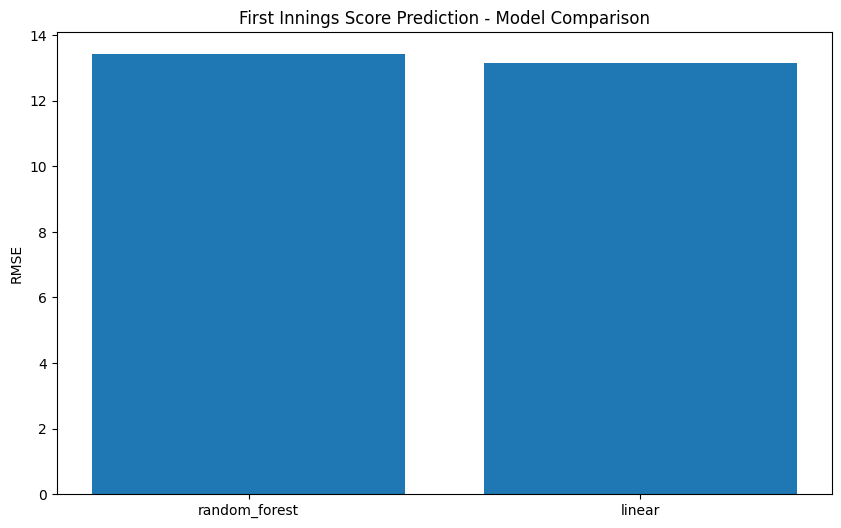

In [6]:
def train_innings_score_model(data):
    
    data[['Team1', 'Team2']] = data['Teams'].str.split(' vs ', expand=True)
    
    features = ['Team1', 'Team2', 'Venue', 'Powerplay_Scores', 'Middle_Overs_Scores']
    target = 'First_Innings_Score'
    
    
    data_processed, label_encoders = preprocess_data(data, features + [target])
    X = data_processed[features]
    y = data_processed[target]
    
   
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    models = {
        'random_forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'linear': LinearRegression()
    }
    
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        results[name] = {
            'model': model,
            'rmse': rmse
        }
        print(f"{name.capitalize()} RMSE: {rmse:.4f}")
    
    
    plt.figure(figsize=(10, 6))
    rmse_scores = [results['rmse'] for results in results.values()]
    plt.bar(models.keys(), rmse_scores)
    plt.title('First Innings Score Prediction - Model Comparison')
    plt.ylabel('RMSE')
    plt.show()
    
    return results, label_encoders

innings_models, innings_encoders = train_innings_score_model(df) 

Win Margin Prediction

Win Margin Prediction RMSE: 13.6867


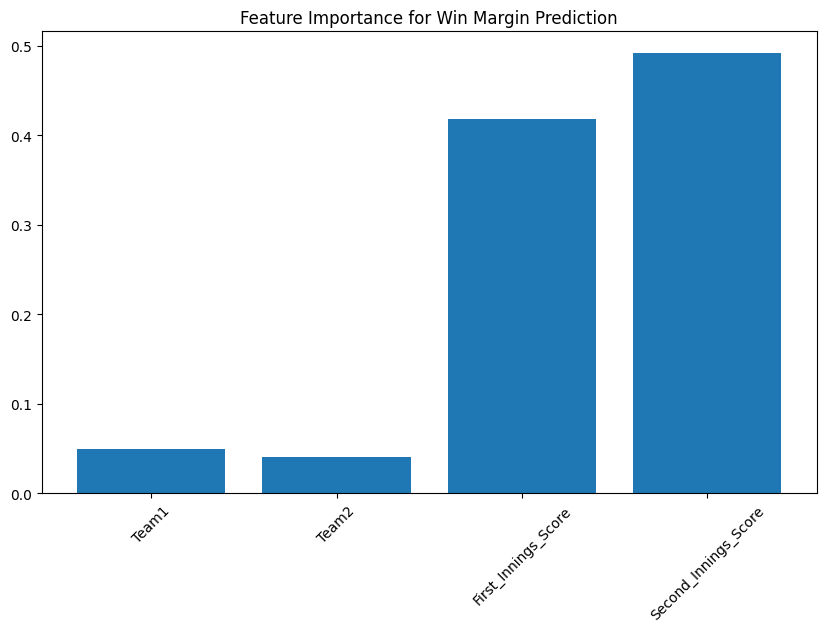

In [7]:

def train_win_margin_model(data):
    data[['Team1', 'Team2']] = data['Teams'].str.split(' vs ', expand=True)
    
    features = ['Team1', 'Team2', 'First_Innings_Score', 'Second_Innings_Score']
    target = 'Win_Margin'
    
    data_processed, label_encoders = preprocess_data(data, features + [target])
    

    if data_processed[target].isna().sum() > 0:
        print("Warning: NaN values detected in target. Filling with mean.")
        data_processed[target] = data_processed[target].fillna(data_processed[target].mean())
    
    X = data_processed[features]
    y = data_processed[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"Win Margin Prediction RMSE: {rmse:.4f}")
    

    plt.figure(figsize=(10, 6))
    importances = model.feature_importances_
    plt.bar(features, importances)
    plt.title('Feature Importance for Win Margin Prediction')
    plt.xticks(rotation=45)
    plt.show()
    
    return model, label_encoders

margin_model, margin_encoders = train_win_margin_model(df)

Over Phase Score Prediction 

In [8]:
def train_phase_score_model(data):
    features = ['Team1', 'Team2', 'Venue']
    targets = ['Powerplay_Scores', 'Middle_Overs_Scores', 'Death_Overs_Scores']
    
    data_processed, label_encoders = preprocess_data(data, features)
    X = data_processed[features]
    y = data_processed[targets]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    
    for i, phase in enumerate(targets):
        rmse = np.sqrt(mean_squared_error(y_test[phase], y_pred[:, i]))
        print(f"{phase} RMSE: {rmse:.4f}")
    
    return model, label_encoders

phase_model, phase_encoders = train_phase_score_model(df)

Powerplay_Scores RMSE: 12.9601
Middle_Overs_Scores RMSE: 19.4168
Death_Overs_Scores RMSE: 17.3253


Win Type Classification

c:\Users\sagar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sagar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sagar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Win Type Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91        90
           1       0.89      0.98      0.93       122
           2       0.00      0.00      0.00         3

    accuracy                           0.92       215
   macro avg       0.62      0.61      0.61       215
weighted avg       0.91      0.92      0.91       215

Accuracy: 0.9163
Precision: 0.9070
Recall: 0.9163


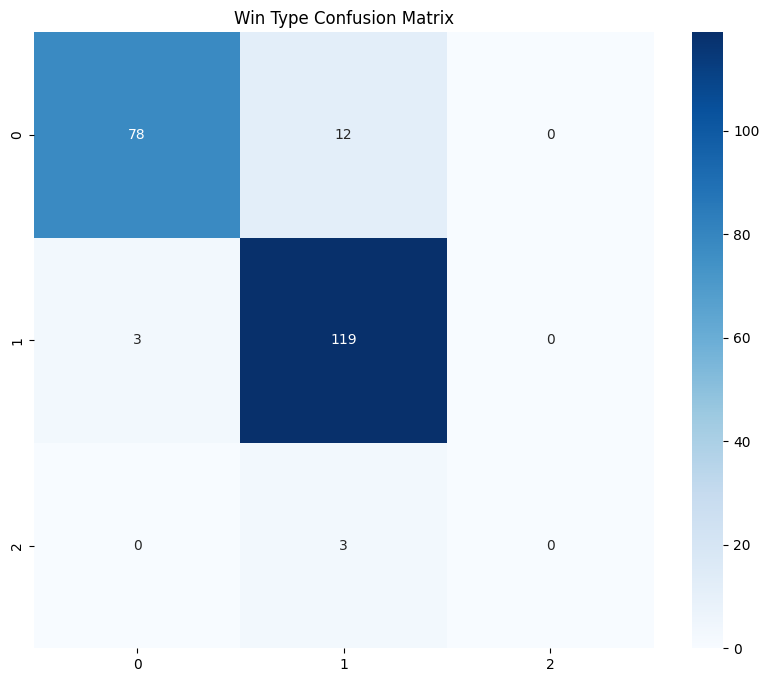

In [9]:
def train_win_type_model(data):
    data[['Team1', 'Team2']] = data['Teams'].str.split(' vs ', expand=True)
    features = ['Team1', 'Team2', 'First_Innings_Score', 'Second_Innings_Score']
    target = 'Win_Type'
    
    data_processed, label_encoders = preprocess_data(data, features + [target])
    X = data_processed[features]
    y = data_processed[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  
    recall = recall_score(y_test, y_pred, average='weighted')

    print("Win Type Classification Report:")
    print(classification_report(y_test, y_pred))
    
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, 
                fmt='d',
                cmap='Blues')
    plt.title('Win Type Confusion Matrix')
    plt.show()
    
    return model, label_encoders, accuracy, precision, recall

win_type_model, win_type_encoders, acc, prec, rec = train_win_type_model(df)


In [10]:
import joblib
import os

def save_all_models():
  
    # save_dir = os.path.join(os.getcwd(), 'saved_models')  
    save_dir = '../save_models'  
    os.makedirs(save_dir, exist_ok=True) 
    models_to_save = {
        'winner': (winner_models, winner_encoders),
        'innings': (innings_models, innings_encoders),
        'margin': (margin_model, margin_encoders),
        'phase': (phase_model, phase_encoders),
        'win_type': (win_type_model, win_type_encoders)
    }
    
    for name, (model, encoders) in models_to_save.items():
        joblib.dump(model, os.path.join(save_dir, f'{name}_model.joblib')) 
        joblib.dump(encoders, os.path.join(save_dir, f'{name}_encoders.joblib')) 
    
    print("All models saved successfully!")

save_all_models()


All models saved successfully!
